### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

C:\Users\SHAILENDRA\AppData\Local\Temp\ipykernel_32116\1871147362.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun


In [3]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [6]:
import arxiv

client = arxiv.Client()

search = arxiv.Search(
    query="Attention Is All You Need",
    max_results=1
)

for result in client.results(search):
    print(result.title)
    print(result.summary)

Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a series of feed-forward layers applied over the patch and feature dimensions in an alternating fashion. In experiments on ImageNet, this architecture performs surprisingly well: a ViT/DeiT-base-sized model obtains 74.9\% top-1 accuracy, compared to 77.9\% and 79.9\% for ViT and DeiT respectively. These results indicate that aspects of vision transformers other than attention, such as the patch embedding

In [7]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [9]:
import requests

url = "https://en.wikipedia.org/w/api.php"
params = {
    "action": "query",
    "list": "search",
    "srsearch": "Machine Learning",
    "format": "json"
}

r = requests.get(url, params=params)

print("Status:", r.status_code)
print("Content-Type:", r.headers.get("Content-Type"))
print(r.text[:500])

Status: 403
Content-Type: text/plain
Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also https://phabricator.wikimedia.org/T400119.



In [10]:
import wikipedia

wikipedia.set_user_agent(
    "MyLangChainBot/1.0 (harry.melina@yahoo.com)"
)

In [11]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [12]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [13]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\SHAILENDRA\AppData\Local\Temp\ipykernel_32116\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [14]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'March 2025: All AI updates from the past month - SD Times',
  'url': 'https://sdtimes.com/ai/march-2025-all-ai-updates-from-the-past-month',
  'content': '“The field of AI wouldn’t be where it is today without decades of work in the academic community. Continued collaboration is essential to build AI that benefits everyone. NextGenAI will accelerate research progress and catalyze a new generation of institutions equipped to harness the transformative power of AI,” said Brad Lightcap, COO of OpenAI.\n\nTeradata launches new solution for efficiently handling vector data for agentic AI use cases\n\nTeradata, a provider of data analytics solutions, announced a new database offering for managing vector data. [...] “Through close collaboration with our customers and partners since the launch of SUSE AI last year, we’ve gained additional and invaluable insights into the challenges of deploying production-ready AI workloads,” said Abhinav Puri, general manager of Portfolio Solution

In [19]:
### Combine all the tools in the list

tools=[
    # arxiv,
    wiki,
    tavily]

In [20]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3.6-27b")

llm_with_tools=llm.bind_tools(tools)

In [21]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': "I will first search for the latest AI news using a search engine to find recent articles and headlines from reputable sources.\nThen, I will look for specific breakthroughs or product launches in the AI field from the last few weeks to ensure the information is up-to-date.\nFinally, I will answer the user's question by summarizing the recent AI news found.\n", 'tool_calls': [{'id': 'f9yp9v1jx', 'function': {'arguments': '{"query":"recent AI news 2024"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 409, 'total_tokens': 521, 'completion_time': 0.212617113, 'completion_tokens_details': {'reasoning_tokens': 74}, 'prompt_time': 0.028912396, 'prompt_tokens_details': None, 'queue_time': 0.054991957, 'total_time': 0.241529509}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_3a782ca0f8', 'service_tier': 'on_demand', 'finish_r

In [22]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'pa46qh47b',
  'type': 'tool_call'}]

In [23]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

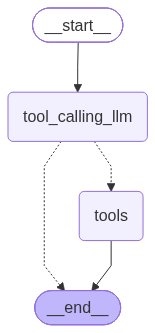

In [24]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [25]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (3k58w1hwk)
 Call ID: 3k58w1hwk
  Args:
    query: arXiv 1706.03762
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "[1706.03762] Attention Is All You Need", "url": "https://arxiv.org/abs/1706.03762", "content": "archive\n\n# Computer Science > Computation and Language\n\n# Title:Attention Is All You Need\n\n|  |  |\n --- |\n| Comments: | 15 pages, 5 figures |\n| Subjects: | Computation and Language (cs.CL); Machine Learning (cs.LG) |\n| Cite as: | arXiv:1706.03762 [cs.CL] |\n|  | (or  arXiv:1706.03762v7 [cs.CL] for this version) |\n|  |  Focus to learn more  arXiv-issued DOI via DataCite |\n\n## Submission history\n\n## Access Paper:\n\n### Current browse context:\n\n### References & Citations\n\n

In [26]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (93khkg9dy)
 Call ID: 93khkg9dy
  Args:
    query: top AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Weekly AI News: 3 March 2025 - AIforBusiness.net", "url": "https://www.youtube.com/watch?v=kw21NJ7YmZM", "content": "This week’s AI update explores some of the most impactful developments shaping technology and society. OpenAI has unveiled GPT-4.5, a cutting-edge model with enhanced intuition and emotional intelligence. While its capabilities push AI closer to human-like perception, its high computational demands raise concerns about accessibility, particularly for smaller businesses.\nMeanwhile, AI is revolutionising taxation. The

In [27]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (mbgepy6ty)
 Call ID: mbgepy6ty
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m
